In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import polars as pl
import matplotlib.pyplot as plt
from primary.preprocessing import cluster_purity
import plotly.express as px
import numpy as np
from primary.pdg_mappings import PDG_ID_TO_NAME

import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from collections import defaultdict, deque

/usr/wipp/conda/24.5.0u/envs/common/lib/python3.11/site-packages/sklearn/utils/_param_validation.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.3)
  from scipy.sparse import csr_matrix, issparse


In [7]:
from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()


with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_particles/train-00000-of-00100.parquet", "rb") as f:
    particles = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_calo_hits/train-00000-of-00100.parquet", "rb") as f:
    calo_hits = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_tracks/train-00000-of-00100.parquet", "rb") as f:
    tracks = pl.read_parquet(f)


In [8]:
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,add_eta_and_phi,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import set_target_particles_mask
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3
#particles = cast_parent_id_to_int64(particles)
particles = add_orphan_mask(particles)
particles = add_created_inside_calo_mask(particles)
particles = add_particle_have_track_mask(particles, tracks)
particles = add_eta_and_phi(particles)
particles = get_particles_id_parent_of_inside_calo_particles_maskv3(particles, calo_hits)
particles = set_target_particles_mask(particles)
particles


Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 4204335 depositors.
Preparing lineage map...
Converged after 5 iterations.


event_id,is_target_particle,enter_calo,has_track,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,perigee_d0,perigee_z0,vertex_primary,parent_id,primary,is_parent_missing,created_inside_calo,eta,phi,pt
u32,list[bool],list[bool],list[bool],list[u64],list[i64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[u16],list[i64],list[bool],list[bool],list[bool],list[f32],list[f32],list[f32]
652,"[false, true, … false]","[false, true, … false]","[false, false, … false]","[57, 58, … 5277]","[-313, -211, … 11]","[0.908738, 0.13957, … 0.000511]","[4.229085, 11.952354, … 0.00052]","[0.0, -1.0, … -1.0]","[0.005982, 0.005982, … 194.004669]","[0.001853, 0.001853, … 494.204834]","[-21.549875, -21.549875, … 1557.38562]","[0.064334, 0.064334, … 6.291512]","[-0.07758, 0.659941, … -0.00009]","[-0.338812, 1.110471, … -0.000028]","[4.115646, 11.881525, … -0.000003]","[0.005418, -0.004196, … NaN]","[-21.512682, -21.592632, … NaN]","[1, 1, … 1]","[7, 7, … 5276]","[true, true, … false]","[true, true, … false]","[false, false, … false]","[3.16648, 2.915061, … -0.033526]","[-1.795892, 1.034586, … -2.837505]","[0.347581, 1.29177, … 0.000094]"
518,"[false, true, … false]","[false, false, … false]","[false, true, … false]","[162, 163, … 3964]","[-521, 211, … 11]","[5.27925, 0.13957, … 0.000511]","[50.060131, 4.334189, … 0.374655]","[-1.0, 1.0, … -1.0]","[0.013214, 0.013214, … 1781.001587]","[0.015358, 0.015358, … -23.163168]","[15.136595, 15.136595, … -1129.980835]","[-0.234114, -0.234114, … 6.882857]","[2.405562, 1.052073, … 0.274503]","[5.290852, 0.337904, … -0.020358]","[-49.440533, -4.188637, … -0.254165]","[-0.005673, 0.010581, … NaN]","[15.302045, 15.202086, … NaN]","[1, 1, … 1]","[8, 8, … 644]","[true, true, … false]","[true, true, … false]","[false, false, … true]","[-2.837424, -2.042634, … -0.826141]","[1.14407, 0.310772, … -0.074026]","[5.812043, 1.105005, … 0.275257]"
253,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[206, 207, … 10961]","[221, 111, … 11]","[0.54785, 0.13498, … 0.000511]","[86.767509, 61.827442, … 0.236554]","[0.0, 0.0, … -1.0]","[0.003757, 0.003757, … -1281.216431]","[-0.026996, -0.026996, … 782.99939]","[58.931355, 58.931355, … -1784.292847]","[0.099754, 0.099754, … 8.035069]","[54.583652, 38.725727, … -0.118177]","[-10.412665, -6.68441, … 0.116624]","[-66.637093, -47.73103, … -0.168495]","[-0.025813, -0.025963, … NaN]","[58.941845, 58.941425, … NaN]","[1, 1, … 1]","[9, 9, … 10960]","[true, true, … false]","[true, true, … false]","[false, false, … true]","[-1.015461, -1.025274, … -0.891821]","[-0.1885, -0.170925, … 2.36281]","[55.567963, 39.298386, … 0.166033]"
777,"[false, true, … false]","[false, true, … false]","[false, true, … false]","[165, 166, … 8850]","[-521, 321, … 2212]","[5.27925, 0.49368, … 0.938272]","[156.945114, 13.257682, … 1.045295]","[-1.0, 1.0, … 1.0]","[0.001572, 0.001572, … 961.811951]","[-0.008819, -0.008819, … -1098.893433]","[44.240398, 44.240398, … 2862.112305]","[0.269996, 0.269996, … 10.950574]","[52.709202, 4.705897, … -0.0691]","[-51.386688, -2.920094, … -0.449419]","[138.510086, 12.035363, … 0.074393]","[-0.005217, -0.006665, … NaN]","[44.226696, 44.227386, … NaN]","[1, 1, … 1]","[9, 9, … 8782]","[true, true, … false]","[true, true, … false]","[false, false, … true]","[1.389397, 1.518484, … 0.162889]","[-0.772694, -0.55537, … -1.723355]","[73.612846, 5.538269, … 0.4547]"
393,"[true, true, … false]","[false, true, … false]","[true, true, … false]","[65, 66, … 6797]","[-211, 211, … 2212]","[0.13957, 0.13957, … 0.938272]","[8.791349, 3.546382, … 1.217234]","[-1.0, 1.0, … 1.0]","[-0.002553, -0.002553, … 1541.634399]","[-0.00393, -0.00393, … 961.824402]","[43.09972, 43.09972, … 27.119455]","[0.018686, 0.018686, … 6.474351]","[8.038111, 3.383335, … -0.137164]","[3.534456, 0.903935, … 0.680441]","[0.405885, -0.541562, … 0.345674]","[-0.00257, -0.003138, … -1701.298462]","[43.099899, 43.

In [ ]:
from primary.preprocessing import add_cluster_labels
calo = add_cluster_labels(
    calo_hits=(
        calo_hits.filter(pl.col("event_id") <1000)
    ), R=0.4)

Preparing data...
Distributing 1000 events across 32 cores...
Aggregating results...


In [9]:
from primary.preprocessing import backtrack_to_target
target = (particles.lazy()
        .select(['event_id','particle_id', 'is_target_particle'])
          .explode(['is_target_particle', 'particle_id'])
          .filter(pl.col('is_target_particle'))
          ).collect(streaming=True)
base  =(
        calo_hits.lazy()
        .select(['event_id', 'contrib_particle_ids'])
        .explode('contrib_particle_ids')
        .explode('contrib_particle_ids') # Double explode if list[list]
        .rename({'contrib_particle_ids': 'particle_id'})
        .unique(subset=['event_id', 'particle_id'])
        .select([
            pl.col('event_id'),
            pl.col('particle_id').cast(pl.Int64)
        ])
    )
result = backtrack_to_target(particles, src_df=base, target_df=target)
result

/tmp/ipykernel_984563/2526740024.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  ).collect(streaming=True)


Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 12 iterations.
Step 4: Final validation...


event_id,src_particle_id,target_particle_id
u32,i64,i64
9,5263,5250
9,4137,1053
9,6578,6577
9,3891,1085
9,4184,1051
…,…,…
506,3002,95
506,3136,95
506,2100,584


# Calo clustering

In [10]:
from primary.preprocessing import add_ms_cluster_labels

In [11]:
calo = add_ms_cluster_labels(calo_hits.filter(pl.col("event_id") <100), bandwidth=120.0)

--- Starting 3D Clustering (MeanShift, bandwidth=120.0) ---
Flattening data...
Preparing 100 events...
Distributing across 32 cores...
Aggregating results...


In [12]:
from primary.preprocessing import number_of_particles_per_cluster,number_of_clusters_per_particle
p = number_of_particles_per_cluster(calo, result, cut_off_percent=0.05)
c = number_of_clusters_per_particle(calo, result, cut_off_percent=0.05)

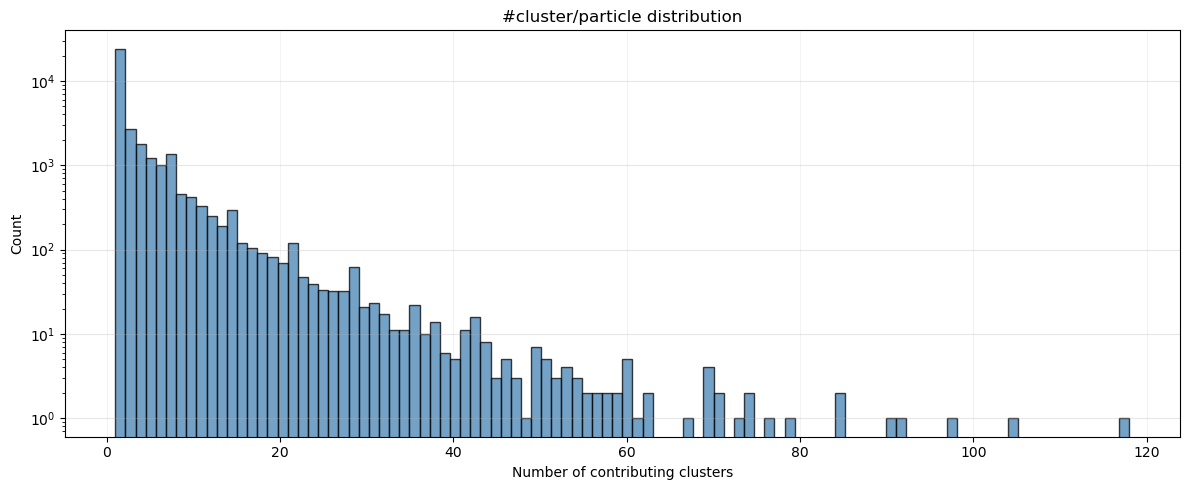

In [13]:
import numpy as np
import matplotlib.pyplot as plt
ancestor_stats = c
# 1. Get the data
data = ancestor_stats["num_contributing_clusters"].to_numpy()

# 2. Calculate min/max to define discrete integer bins
min_val = int(data.min())
max_val = int(data.max())



# 3. Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(data, bins=100, color="steelblue", edgecolor="black", alpha=0.75)


ax.set_xlabel("Number of contributing clusters")
ax.set_ylabel("Count")
ax.set_title("#cluster/particle distribution")

# 5. Grid settings
# 'axis="x"' puts vertical lines between the values to separate them visually
# or strictly on the ticks depending on how matplotlib renders the layout.
ax.grid(axis="y", alpha=0.3) 
ax.grid(axis="x", alpha=0.15) # Add faint vertical grid lines for clarity
# log scale
ax.set_yscale("log")
plt.tight_layout()
plt.show()

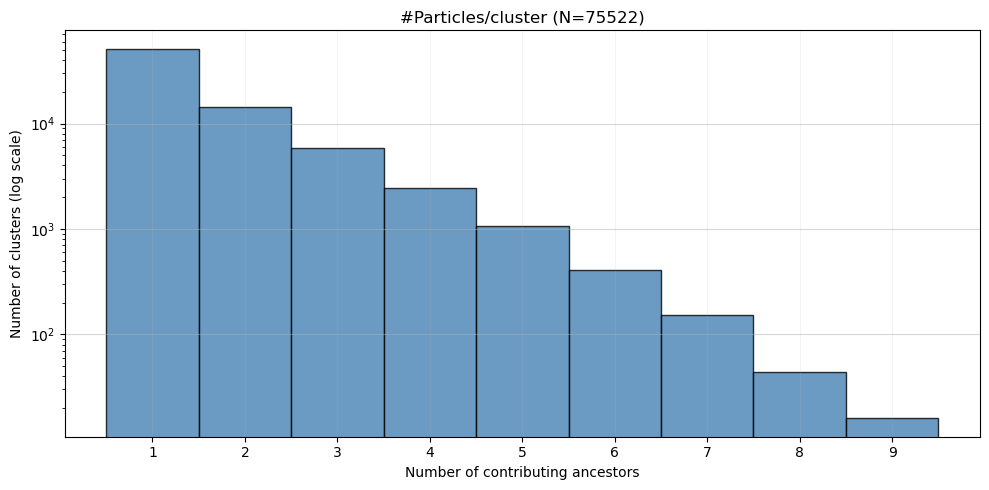

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.ticker import MaxNLocator

def plot_num_contributing_ancestors(cluster_stats_df: pl.DataFrame, log_scale: bool = False) -> None:
    """
    Histogram of 'num_contributing_ancestors' where every integer has its own explicit bar.
    """
    vals = cluster_stats_df["num_contributing_ancestors"].to_numpy()
    
    if len(vals) == 0:
        print("No data to plot.")
        return

    # 1. Determine Range for Discrete Bins
    min_val = int(vals.min())
    max_val = int(vals.max())
    
    # Create bins centered on integers: [0.5, 1.5, 2.5, ...]
    # This ensures the bar for "1" is exactly between 0.5 and 1.5
    discrete_bins = np.arange(min_val - 0.5, max_val + 1.5, 1)

    # 2. Plot
    plt.figure(figsize=(10, 5))
    plt.hist(vals, bins=discrete_bins, color="steelblue", edgecolor="black", alpha=0.8)
    
    plt.xlabel("Number of contributing ancestors")
    plt.ylabel("Number of clusters")
    plt.title(f"#Particles/cluster (N={len(vals)})")

    # 3. Handle Ticks
    # If the range is small (e.g., 1 to 20), show every single number.
    # If the range is huge, let Matplotlib pick, but force them to be Integers.
    if max_val - min_val <= 30:
        plt.xticks(range(min_val, max_val + 1))
    else:
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    # 4. Log Scale & Grid
    if log_scale:
        plt.yscale("log")
        plt.ylabel("Number of clusters (log scale)")
    
    plt.grid(axis="y", alpha=0.5)
    plt.grid(axis="x", alpha=0.15) # Faint vertical lines to separate values
    # log scale

    plt.tight_layout()
    plt.show()
# ...existing code...

plot_num_contributing_ancestors(p, log_scale=True)

/tmp/ipykernel_984563/3785030947.py:19: DeprecationWarning:

the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.



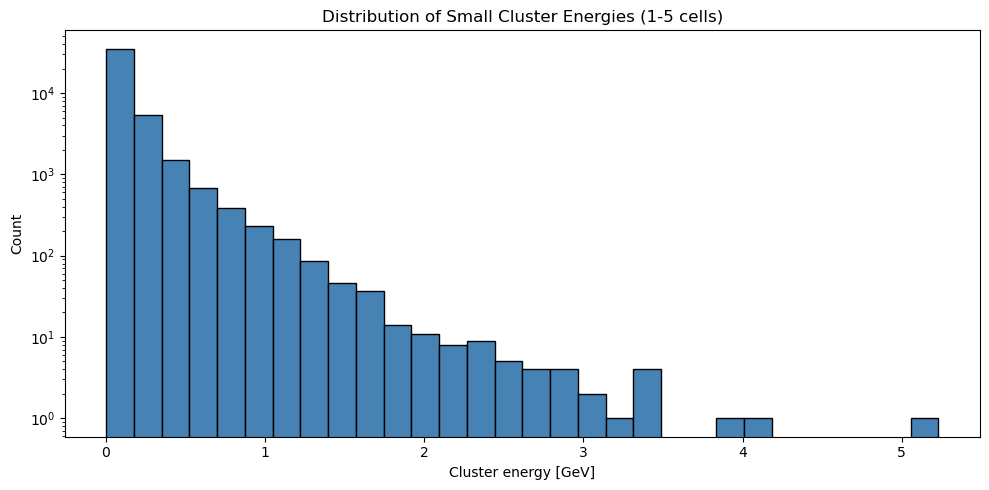

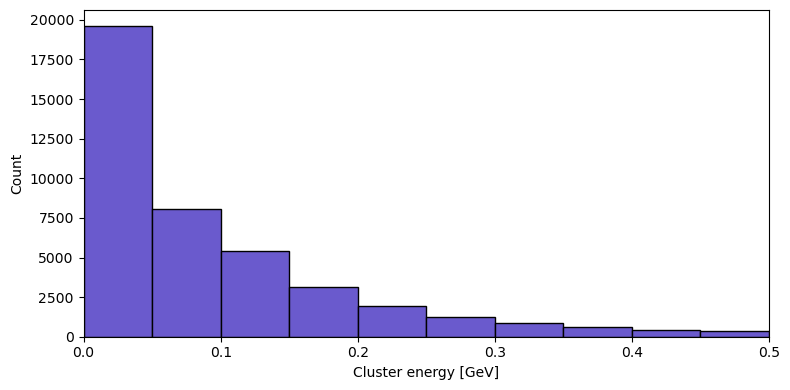

In [41]:
from primary.preprocessing import CALIBRATION
small_cluster_stats = (
    calo.lazy()
    .select(['event_id', 'cluster_id', 'detector', 'total_energy'])
    .explode(['cluster_id', 'total_energy', 'detector'])
    .join(
        CALIBRATION.lazy().select(['detector', 'calib_factor']),
        on='detector',
    )
    .group_by(["event_id", "cluster_id"])
    .agg([
        pl.len().alias("cluster_size"),
        (pl.col("total_energy") * pl.col("calib_factor")).sum().alias("cluster_energy")
    ])
    .filter(
        (pl.col("cluster_size") >= 1) & 
        (pl.col("cluster_size") <= 5) 
    )
) .collect(streaming=True)

plt.figure(figsize=(10, 5))
plt.hist(
    small_cluster_stats["cluster_energy"].to_numpy(),
    bins=30,
    color="steelblue",
    edgecolor="black",
)
plt.yscale("log")
plt.xlabel("Cluster energy [GeV]")
plt.ylabel("Count")
# add title
plt.title("Distribution of Small Cluster Energies (1-5 cells)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(
    small_cluster_stats["cluster_energy"].to_numpy(),
    bins=np.linspace(0.0, 0.5, 11),
    color="slateblue",
    edgecolor="black",
)
plt.xlim(0.0, 0.5)
plt.xlabel("Cluster energy [GeV]")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [42]:


cluster_stats = (
    calo.lazy()
    .select(["event_id", "cluster_id"])
    .explode("cluster_id")
    .group_by(["event_id", "cluster_id"])
    .agg(pl.count().alias("count"))
    .rename({"count": "cluster_size"})
    .collect()
)
size_cdf = (
    cluster_stats.lazy()
    .group_by("cluster_size")
    .agg(pl.count().alias("num_clusters"))
    .sort("cluster_size")
    .collect()
    .with_columns([
        pl.col("num_clusters").cum_sum().shift(1).fill_null(0).alias("clusters_lt"),
    ])
    .with_columns([
        (pl.col("clusters_lt") / pl.col("num_clusters").sum() * 100).alias("percentage_lt"),
    ])
)

fig = go.Figure(
    go.Scatter(
        x=size_cdf["cluster_size"],
        y=size_cdf["percentage_lt"],
        mode="markers+lines",
        marker=dict(size=8, color="mediumslateblue"),
        hovertemplate="Cluster size < %{x}<br>Share: %{y:.2f}%<extra></extra>",
    )
)
fig.update_layout(
    title="Cumulative share of clusters by size",
    xaxis_title="Cluster size (cells)",
    yaxis_title="Percentage of clusters",
    yaxis=dict(range=[0, 100]),
)
fig.show()



cluster_energy_stats = (
    calo.lazy()
    .select(["event_id", "cluster_id", "detector", "total_energy"])
    .explode(["cluster_id", "detector", "total_energy"])
    .join(
        CALIBRATION.lazy().select(["detector", "calib_factor"]),
        on="detector",
    )
    .group_by(["event_id", "cluster_id"])
    .agg([
        pl.len().alias("cluster_size"),
        (pl.col("total_energy") * pl.col("calib_factor")).sum().alias("cluster_energy"),
    ])
    .collect(streaming=True)
)

# 2. Calculate Global Energy Distribution
energy_cdf = (
    cluster_energy_stats.lazy()
    # BUG FIX: Group ONLY by cluster_size. 
    # We want to sum the energy of ALL clusters of size X in the entire dataset.
    .group_by("cluster_size")
    .agg([
        pl.col("cluster_energy").sum().alias("total_energy_at_size"),
    ])
    .sort("cluster_size")
    .with_columns([
        # Cumulative sum of the GLOBAL energy
        pl.col("total_energy_at_size")
        .cum_sum()
        .shift(1)
        .fill_null(0)
        .alias("energy_lt_global")
    ])
    .with_columns([
        # Normalize by the grand total energy of the entire dataset
        (pl.col("energy_lt_global") / pl.col("total_energy_at_size").sum() * 100)
        .alias("avg_energy_pct")
    ])
    .collect()
)

# 3. Plot
fig = go.Figure(
    go.Scatter(
        x=energy_cdf["cluster_size"],
        y=energy_cdf["avg_energy_pct"],
        mode="markers+lines",
        marker=dict(size=6, color="darkorchid"),
        line=dict(width=2),
        hovertemplate="Cluster size < %{x}<br>Total Energy share: %{y:.2f}%<extra></extra>",
    )
)
fig.update_layout(
    title="Cumulative share of energy by cluster size (Global)",
    xaxis_title="Cluster size (cells)",
    yaxis_title="Energy share [%]",
    yaxis=dict(range=[0, 100]),
    template="plotly_white"
)
fig.show()

/tmp/ipykernel_984563/85203925.py:6: DeprecationWarning:

`pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)

/tmp/ipykernel_984563/85203925.py:13: DeprecationWarning:

`pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)



/tmp/ipykernel_984563/85203925.py:56: DeprecationWarning:

the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.



/tmp/ipykernel_984563/3134915839.py:6: DeprecationWarning:

`count` was renamed; use `len` instead

/tmp/ipykernel_984563/3134915839.py:15: DeprecationWarning:

`pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)



,event_id,num_clusters,max_cluster_size
0,0,331,2364
1,1,415,2558
2,2,594,2058
3,3,714,1947
4,4,485,1963
...,...,...,...
95,95,618,2831
96,96,841,3249
97,97,992,12493
98,98,687,3071


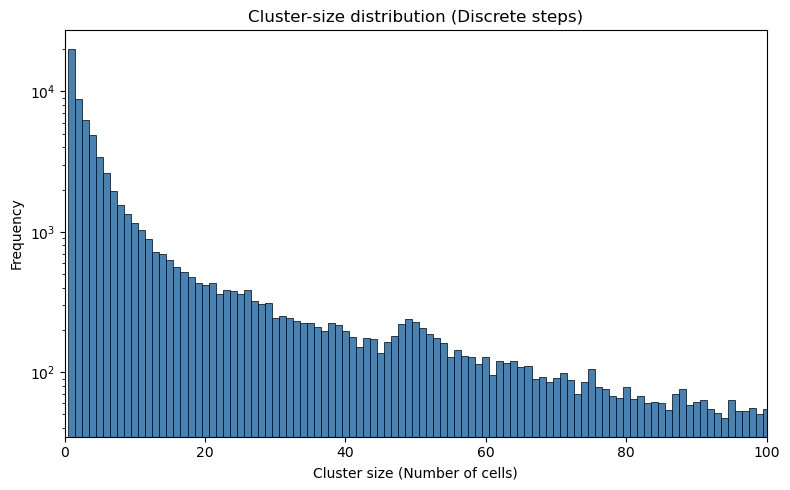

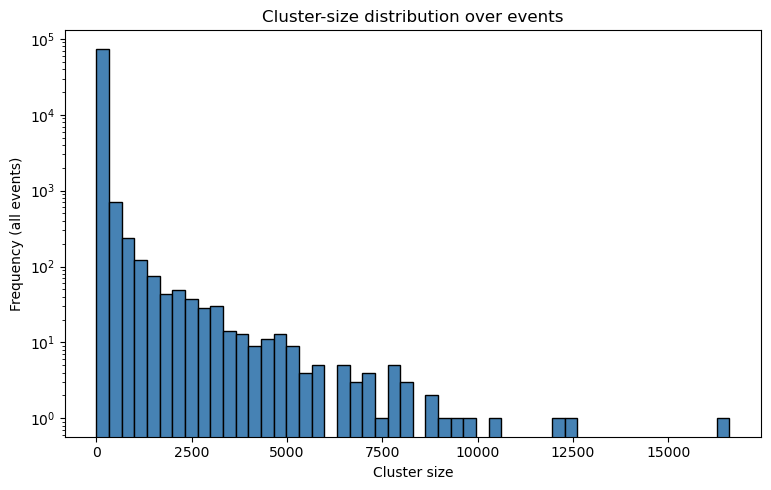

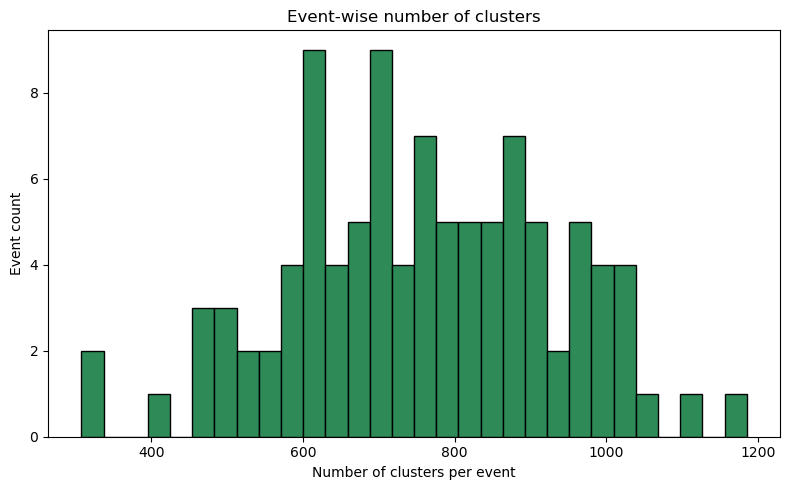

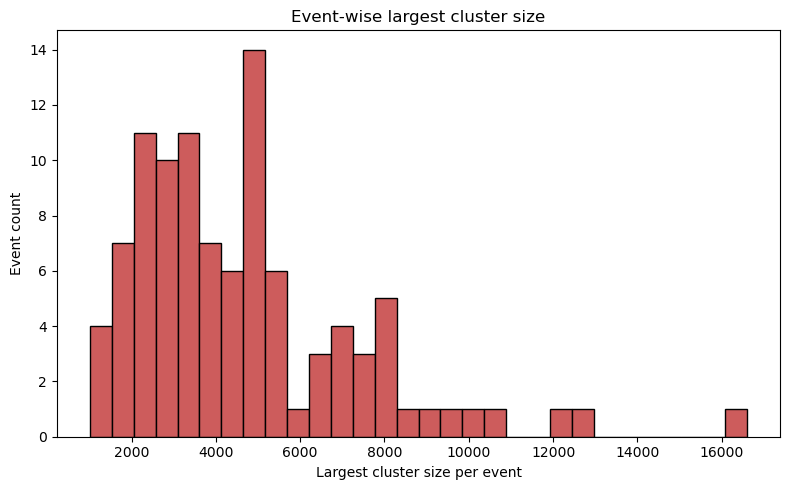

In [43]:
cluster_stats = (
    calo.lazy()
    .select(["event_id", "cluster_id"])
    .explode("cluster_id")
    .group_by(["event_id", "cluster_id"])
    .count()
    .rename({"count": "cluster_size"})
    .collect()
)

event_summary = (
    cluster_stats.lazy()
    .group_by("event_id")
    .agg([
        pl.count().alias("num_clusters"),
        pl.col("cluster_size").max().alias("max_cluster_size"),
    ])
    .sort("event_id")
    .collect()
)

display(event_summary.to_pandas())

plt.figure(figsize=(8, 5))

# Create bins centered on integers: 
# Edges at 0.5, 1.5, 2.5 ... 100.5
# This creates exactly one bin for every integer from 1 to 100
bins = np.arange(0, 102) - 0.5 

plt.hist(
    cluster_stats["cluster_size"].to_numpy(), 
    bins=bins, 
    color="steelblue", 
    edgecolor="black",
    linewidth=0.5 # Thinner edges look better for many bins
)

plt.xlim(0, 100)  # Focus on the 0-100 range
plt.yscale('log')

plt.xlabel("Cluster size (Number of cells)")
plt.ylabel("Frequency")
plt.title("Cluster-size distribution (Discrete steps)")
plt.tight_layout()

plt.show()


plt.figure(figsize=(8, 5))
plt.hist(cluster_stats["cluster_size"].to_numpy(), bins=50, color="steelblue", edgecolor="black")
plt.xlabel("Cluster size")
plt.ylabel("Frequency (all events)")
plt.title("Cluster-size distribution over events")
plt.tight_layout()
plt.yscale('log')

plt.show()

plt.figure(figsize=(8, 5))
plt.hist(event_summary["num_clusters"].to_numpy(), bins=30, color="seagreen", edgecolor="black")
plt.xlabel("Number of clusters per event")
plt.ylabel("Event count")
plt.title("Event-wise number of clusters")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(event_summary["max_cluster_size"].to_numpy(), bins=30, color="indianred", edgecolor="black")
plt.xlabel("Largest cluster size per event")
plt.ylabel("Event count")
plt.title("Event-wise largest cluster size")
plt.tight_layout()
plt.show()

In [50]:
from primary.interactive_plot import plot_calo_clusters_interactive
plot_calo_clusters_interactive(
    calo_hits=calo, 
    event_idx=4, 
    min_cluster_size=1,
    show=True
)

In [47]:
particles

event_id,is_target_particle,enter_calo,has_track,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,perigee_d0,perigee_z0,vertex_primary,parent_id,primary,is_parent_missing,created_inside_calo,eta,phi,pt
u32,list[bool],list[bool],list[bool],list[u64],list[i64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[u16],list[i64],list[bool],list[bool],list[bool],list[f32],list[f32],list[f32]
652,"[false, true, … false]","[false, true, … false]","[false, false, … false]","[57, 58, … 5277]","[-313, -211, … 11]","[0.908738, 0.13957, … 0.000511]","[4.229085, 11.952354, … 0.00052]","[0.0, -1.0, … -1.0]","[0.005982, 0.005982, … 194.004669]","[0.001853, 0.001853, … 494.204834]","[-21.549875, -21.549875, … 1557.38562]","[0.064334, 0.064334, … 6.291512]","[-0.07758, 0.659941, … -0.00009]","[-0.338812, 1.110471, … -0.000028]","[4.115646, 11.881525, … -0.000003]","[0.005418, -0.004196, … NaN]","[-21.512682, -21.592632, … NaN]","[1, 1, … 1]","[7, 7, … 5276]","[true, true, … false]","[true, true, … false]","[false, false, … false]","[3.16648, 2.915061, … -0.033526]","[-1.795892, 1.034586, … -2.837505]","[0.347581, 1.29177, … 0.000094]"
518,"[false, true, … false]","[false, false, … false]","[false, true, … false]","[162, 163, … 3964]","[-521, 211, … 11]","[5.27925, 0.13957, … 0.000511]","[50.060131, 4.334189, … 0.374655]","[-1.0, 1.0, … -1.0]","[0.013214, 0.013214, … 1781.001587]","[0.015358, 0.015358, … -23.163168]","[15.136595, 15.136595, … -1129.980835]","[-0.234114, -0.234114, … 6.882857]","[2.405562, 1.052073, … 0.274503]","[5.290852, 0.337904, … -0.020358]","[-49.440533, -4.188637, … -0.254165]","[-0.005673, 0.010581, … NaN]","[15.302045, 15.202086, … NaN]","[1, 1, … 1]","[8, 8, … 644]","[true, true, … false]","[true, true, … false]","[false, false, … true]","[-2.837424, -2.042634, … -0.826141]","[1.14407, 0.310772, … -0.074026]","[5.812043, 1.105005, … 0.275257]"
253,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[206, 207, … 10961]","[221, 111, … 11]","[0.54785, 0.13498, … 0.000511]","[86.767509, 61.827442, … 0.236554]","[0.0, 0.0, … -1.0]","[0.003757, 0.003757, … -1281.216431]","[-0.026996, -0.026996, … 782.99939]","[58.931355, 58.931355, … -1784.292847]","[0.099754, 0.099754, … 8.035069]","[54.583652, 38.725727, … -0.118177]","[-10.412665, -6.68441, … 0.116624]","[-66.637093, -47.73103, … -0.168495]","[-0.025813, -0.025963, … NaN]","[58.941845, 58.941425, … NaN]","[1, 1, … 1]","[9, 9, … 10960]","[true, true, … false]","[true, true, … false]","[false, false, … true]","[-1.015461, -1.025274, … -0.891821]","[-0.1885, -0.170925, … 2.36281]","[55.567963, 39.298386, … 0.166033]"
777,"[false, true, … false]","[false, true, … false]","[false, true, … false]","[165, 166, … 8850]","[-521, 321, … 2212]","[5.27925, 0.49368, … 0.938272]","[156.945114, 13.257682, … 1.045295]","[-1.0, 1.0, … 1.0]","[0.001572, 0.001572, … 961.811951]","[-0.008819, -0.008819, … -1098.893433]","[44.240398, 44.240398, … 2862.112305]","[0.269996, 0.269996, … 10.950574]","[52.709202, 4.705897, … -0.0691]","[-51.386688, -2.920094, … -0.449419]","[138.510086, 12.035363, … 0.074393]","[-0.005217, -0.006665, … NaN]","[44.226696, 44.227386, … NaN]","[1, 1, … 1]","[9, 9, … 8782]","[true, true, … false]","[true, true, … false]","[false, false, … true]","[1.389397, 1.518484, … 0.162889]","[-0.772694, -0.55537, … -1.723355]","[73.612846, 5.538269, … 0.4547]"
393,"[true, true, … false]","[false, true, … false]","[true, true, … false]","[65, 66, … 6797]","[-211, 211, … 2212]","[0.13957, 0.13957, … 0.938272]","[8.791349, 3.546382, … 1.217234]","[-1.0, 1.0, … 1.0]","[-0.002553, -0.002553, … 1541.634399]","[-0.00393, -0.00393, … 961.824402]","[43.09972, 43.09972, … 27.119455]","[0.018686, 0.018686, … 6.474351]","[8.038111, 3.383335, … -0.137164]","[3.534456, 0.903935, … 0.680441]","[0.405885, -0.541562, … 0.345674]","[-0.00257, -0.003138, … -1701.298462]","[43.099899, 43.

# Event partitionning

In [45]:
from primary.preprocessing import cluster_purity
pur = cluster_purity(calo, result)

In [46]:
from primary.preprocessing import number_of_particles_per_cluster,number_of_clusters_per_particle
p = number_of_particles_per_cluster(calo, result, cut_off_percent=0.05)
c = number_of_clusters_per_particle(calo, result, cut_off_percent=0.05)

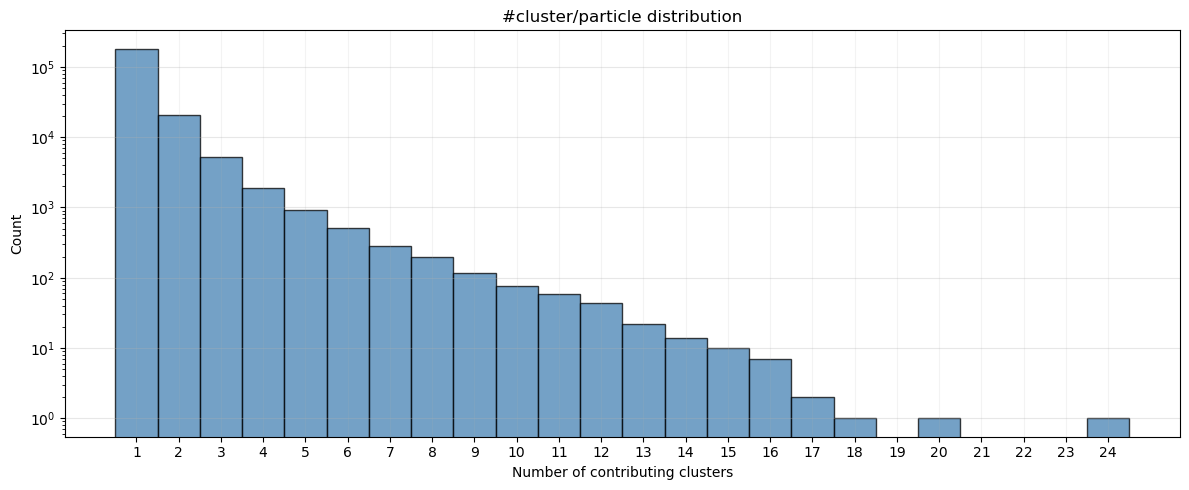

In [47]:
import numpy as np
import matplotlib.pyplot as plt
ancestor_stats = c
# 1. Get the data
data = ancestor_stats["num_contributing_clusters"].to_numpy()

# 2. Calculate min/max to define discrete integer bins
min_val = int(data.min())
max_val = int(data.max())

# Create bins that wrap around the integers: [0.5, 1.5, 2.5, ...]
# This ensures the bar for "1" is centered exactly on 1.
bins = np.arange(min_val - 0.5, max_val + 1.5, 1)

# 3. Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(data, bins=bins, color="steelblue", edgecolor="black", alpha=0.75)

# 4. Force X-axis ticks to show every single integer
ax.set_xticks(range(min_val, max_val + 1))
ax.set_xlabel("Number of contributing clusters")
ax.set_ylabel("Count")
ax.set_title("#cluster/particle distribution")

# 5. Grid settings
# 'axis="x"' puts vertical lines between the values to separate them visually
# or strictly on the ticks depending on how matplotlib renders the layout.
ax.grid(axis="y", alpha=0.3) 
ax.grid(axis="x", alpha=0.15) # Add faint vertical grid lines for clarity
# log scale
ax.set_yscale("log")
plt.tight_layout()
plt.show()

In [48]:
c.sort('num_contributing_clusters', descending=True)

event_id,ultimate_ancestor_id,num_contributing_clusters,max_ancestor_energy_deps_in_cluster
u32,i64,u32,f64
31,482,24,58.629905
981,512,20,310.179804
563,398,18,4.724927
124,939,17,3.736874
291,443,17,110.044315
…,…,…,…
5,798,1,2.049822
32,237,1,0.04091
450,3968,1,9.811376


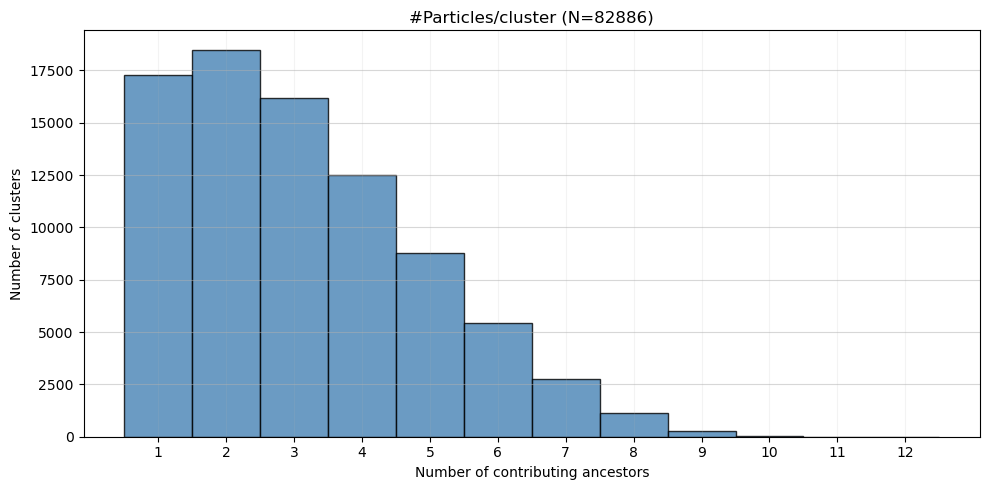

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.ticker import MaxNLocator

def plot_num_contributing_ancestors(cluster_stats_df: pl.DataFrame, log_scale: bool = False) -> None:
    """
    Histogram of 'num_contributing_ancestors' where every integer has its own explicit bar.
    """
    vals = cluster_stats_df["num_contributing_ancestors"].to_numpy()
    
    if len(vals) == 0:
        print("No data to plot.")
        return

    # 1. Determine Range for Discrete Bins
    min_val = int(vals.min())
    max_val = int(vals.max())
    
    # Create bins centered on integers: [0.5, 1.5, 2.5, ...]
    # This ensures the bar for "1" is exactly between 0.5 and 1.5
    discrete_bins = np.arange(min_val - 0.5, max_val + 1.5, 1)

    # 2. Plot
    plt.figure(figsize=(10, 5))
    plt.hist(vals, bins=discrete_bins, color="steelblue", edgecolor="black", alpha=0.8)
    
    plt.xlabel("Number of contributing ancestors")
    plt.ylabel("Number of clusters")
    plt.title(f"#Particles/cluster (N={len(vals)})")

    # 3. Handle Ticks
    # If the range is small (e.g., 1 to 20), show every single number.
    # If the range is huge, let Matplotlib pick, but force them to be Integers.
    if max_val - min_val <= 30:
        plt.xticks(range(min_val, max_val + 1))
    else:
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    # 4. Log Scale & Grid
    if log_scale:
        plt.yscale("log")
        plt.ylabel("Number of clusters (log scale)")
    
    plt.grid(axis="y", alpha=0.5)
    plt.grid(axis="x", alpha=0.15) # Faint vertical lines to separate values
    plt.tight_layout()
    plt.show()
# ...existing code...

plot_num_contributing_ancestors(p, log_scale=False)

/tmp/ipykernel_798826/3461637387.py:6: DeprecationWarning: `count` was renamed; use `len` instead
  .count()
/tmp/ipykernel_798826/3461637387.py:15: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("num_clusters"),


,event_id,num_clusters,max_cluster_size
0,0,73,2424
1,1,73,3186
2,2,75,4697
3,3,83,2693
4,4,88,2496
...,...,...,...
995,995,92,9466
996,996,87,5543
997,997,90,10753
998,998,63,4239


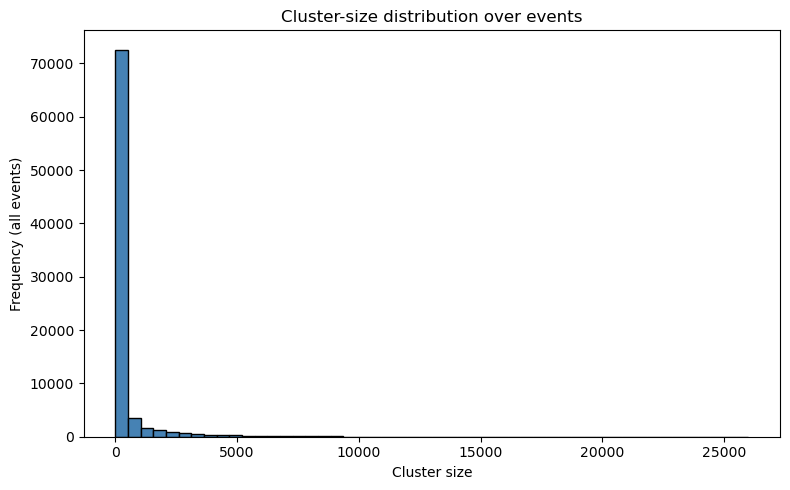

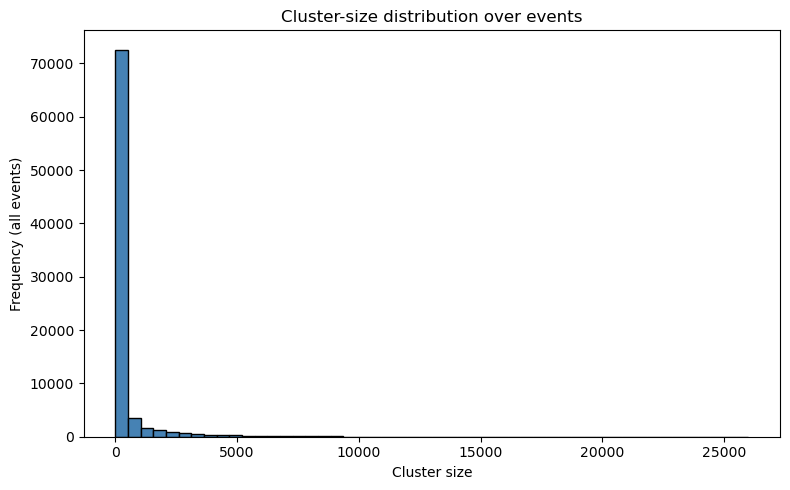

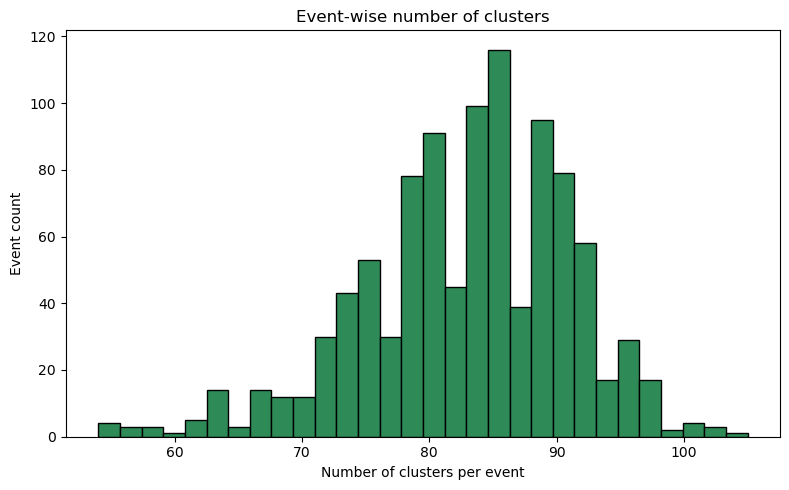

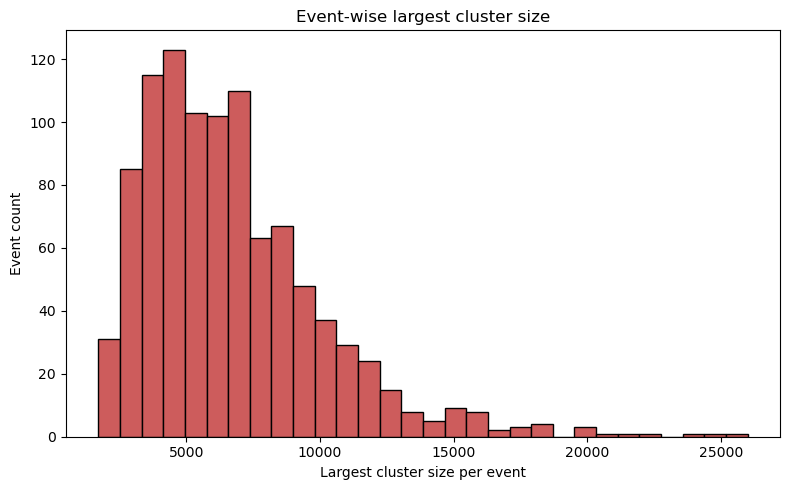

In [50]:
cluster_stats = (
    calo.lazy()
    .select(["event_id", "cluster_id"])
    .explode("cluster_id")
    .group_by(["event_id", "cluster_id"])
    .count()
    .rename({"count": "cluster_size"})
    .collect()
)

event_summary = (
    cluster_stats.lazy()
    .group_by("event_id")
    .agg([
        pl.count().alias("num_clusters"),
        pl.col("cluster_size").max().alias("max_cluster_size"),
    ])
    .sort("event_id")
    .collect()
)

display(event_summary.to_pandas())

plt.figure(figsize=(8, 5))
plt.hist(cluster_stats["cluster_size"].to_numpy(), bins=50, color="steelblue", edgecolor="black")
plt.xlabel("Cluster size")
plt.ylabel("Frequency (all events)")
plt.title("Cluster-size distribution over events")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(cluster_stats["cluster_size"].to_numpy(), bins=50, color="steelblue", edgecolor="black")
plt.xlabel("Cluster size")
plt.ylabel("Frequency (all events)")
plt.title("Cluster-size distribution over events")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(event_summary["num_clusters"].to_numpy(), bins=30, color="seagreen", edgecolor="black")
plt.xlabel("Number of clusters per event")
plt.ylabel("Event count")
plt.title("Event-wise number of clusters")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(event_summary["max_cluster_size"].to_numpy(), bins=30, color="indianred", edgecolor="black")
plt.xlabel("Largest cluster size per event")
plt.ylabel("Event count")
plt.title("Event-wise largest cluster size")
plt.tight_layout()
plt.show()

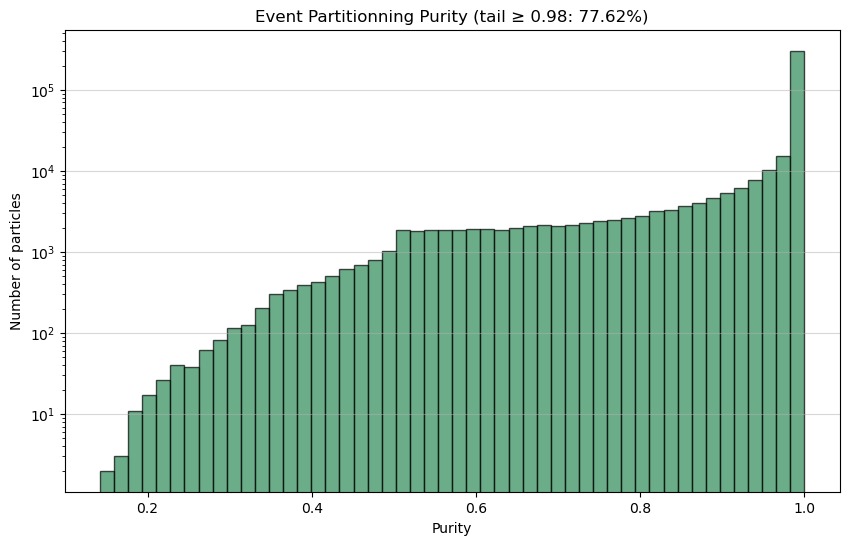

In [51]:
from primary.plot import plot_clusters_purity
purity_df = plot_clusters_purity(calo, result)

In [52]:
cluster_labels

NameError: name 'cluster_labels' is not defined

In [ ]:
constituents[0].user_index()

39578

In [ ]:
(
    calo_hits.lazy()
    .filter(pl.col("event_id") == 5)
    .select('x', 'y', 'z', 'total_energy')
    .explode('x', 'y', 'z', 'total_energy')
).collect(streaming=True)

/tmp/ipykernel_2501669/974053181.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  ).collect(streaming=True)


x,y,z,total_energy
f32,f32,f32,f32
353.82843,505.29071,3263.0,0.000127
-439.516754,-1260.991455,40.799999,0.000505
1129.478394,313.279694,3318.550049,0.018525
-86.699997,1272.599976,1203.599976,0.001721
-56.099998,367.788971,3232.699951,0.000137
…,…,…,…
927.221313,-681.996704,3293.300049,0.000211
-681.996704,-537.746887,3323.600098,0.000278
726.764343,-1072.963867,2779.5,0.000352
